In [ ]:
import os
import os.path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
import cv2
import dlib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
import kagglehub
from scipy.spatial import distance
import time


In [ ]:
dataset_path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", dataset_path)
dataset_path = dataset_path + "/test/"
emotions = mcolors = ['angry','disgust','fear','happy','sad','surprise','neutral']
emotion_paths = {emotion: os.path.join(dataset_path, emotion) for emotion in emotions}

print(emotion_paths)

Path to dataset files: /kaggle/input/fer2013
{'angry': '/kaggle/input/fer2013/test/angry', 'disgust': '/kaggle/input/fer2013/test/disgust', 'fear': '/kaggle/input/fer2013/test/fear', 'happy': '/kaggle/input/fer2013/test/happy', 'sad': '/kaggle/input/fer2013/test/sad', 'surprise': '/kaggle/input/fer2013/test/surprise', 'neutral': '/kaggle/input/fer2013/test/neutral'}


Emotions available: ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
Number of angry images: 958
Sample paths: ['/kaggle/input/fer2013/test/angry/PublicTest_3641536.jpg', '/kaggle/input/fer2013/test/angry/PublicTest_21334851.jpg', '/kaggle/input/fer2013/test/angry/PrivateTest_56252993.jpg']
Number of disgust images: 111
Sample paths: ['/kaggle/input/fer2013/test/disgust/PublicTest_58268614.jpg', '/kaggle/input/fer2013/test/disgust/PublicTest_41393563.jpg', '/kaggle/input/fer2013/test/disgust/PublicTest_85498443.jpg']
Number of fear images: 1024
Sample paths: ['/kaggle/input/fer2013/test/fear/PublicTest_67261410.jpg', '/kaggle/input/fer2013/test/fear/PrivateTest_80486885.jpg', '/kaggle/input/fer2013/test/fear/PrivateTest_29930852.jpg']
Number of happy images: 1774
Sample paths: ['/kaggle/input/fer2013/test/happy/PrivateTest_6781468.jpg', '/kaggle/input/fer2013/test/happy/PrivateTest_45765115.jpg', '/kaggle/input/fer2013/test/happy/PrivateTest_89950479.jpg']
Number of 

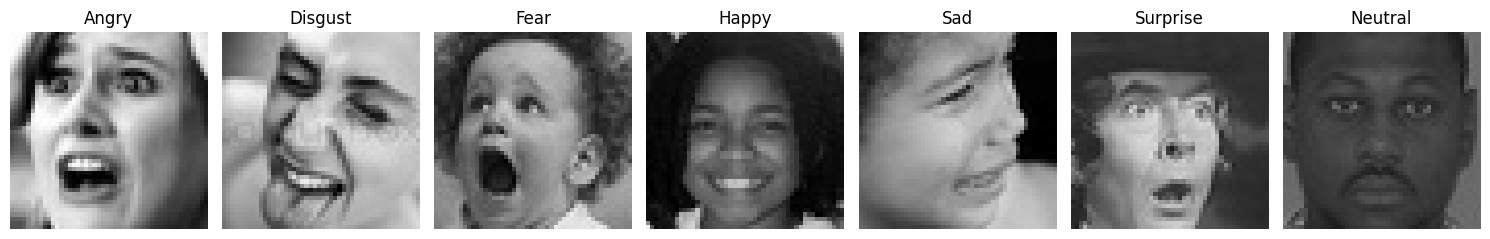


Exploring directory structure:

Checking angry directory: /kaggle/input/fer2013/test/angry
Total files: 958
First few files: ['PublicTest_3641536.jpg', 'PublicTest_21334851.jpg', 'PrivateTest_56252993.jpg', 'PrivateTest_46881419.jpg', 'PrivateTest_88795628.jpg']

Checking disgust directory: /kaggle/input/fer2013/test/disgust
Total files: 111
First few files: ['PublicTest_58268614.jpg', 'PublicTest_41393563.jpg', 'PublicTest_85498443.jpg', 'PublicTest_96161493.jpg', 'PublicTest_48953105.jpg']

Checking fear directory: /kaggle/input/fer2013/test/fear
Total files: 1024
First few files: ['PublicTest_67261410.jpg', 'PrivateTest_80486885.jpg', 'PrivateTest_29930852.jpg', 'PublicTest_61256129.jpg', 'PrivateTest_86063456.jpg']

Checking happy directory: /kaggle/input/fer2013/test/happy
Total files: 1774
First few files: ['PrivateTest_6781468.jpg', 'PrivateTest_45765115.jpg', 'PrivateTest_89950479.jpg', 'PrivateTest_54479403.jpg', 'PrivateTest_35154145.jpg']

Checking sad directory: /kaggle/in

In [ ]:
# Display some information about the dataset
print("Emotions available:", emotions)
for emotion in emotions:
    # Use "*.jpg" pattern to match all JPG files in the directory
    image_files = glob(os.path.join(emotion_paths[emotion], "*.jpg"))
    print(f"Number of {emotion} images: {len(image_files)}")
    # Print first few image paths to verify
    print(f"Sample paths: {image_files[:3] if image_files else 'No images found'}")

# Display a sample image from each emotion category
plt.figure(figsize=(15, 5))
for i, emotion in enumerate(emotions):
    # Use "*.jpg" pattern to match all JPG files in the directory
    image_files = glob(os.path.join(emotion_paths[emotion], "*.jpg"))
    if image_files:
        img = cv2.imread(image_files[0])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, 7, i+1)
        plt.imshow(img)
        plt.title(emotion.capitalize())
        plt.axis('off')
    else:
        plt.subplot(1, 7, i+1)
        plt.text(0.5, 0.5, f"No {emotion} images found",
                ha='center', va='center', transform=plt.gca().transAxes)
        plt.title(emotion.capitalize())
        plt.axis('off')
plt.tight_layout()
plt.show()

# If you're still having issues, let's explore the directory structure directly
print("\nExploring directory structure:")
for emotion in emotions:
    print(f"\nChecking {emotion} directory: {emotion_paths[emotion]}")
    # Check if directory exists
    if os.path.exists(emotion_paths[emotion]):
        # List all files in directory
        files = os.listdir(emotion_paths[emotion])
        print(f"Total files: {len(files)}")
        if files:
            print(f"First few files: {files[:5]}")
        else:
            print("No files found")
    else:
        print("Directory does not exist")

In [ ]:
# Download the face landmark predictor
# Had some trouble with this

# Check if file already exists
if not os.path.exists('/content/shape_predictor_68_face_landmarks.dat'):
    # Method 1: download using google downloader
    !pip install -q gdown
    import gdown

    url = 'https://github.com/davisking/dlib-models/raw/master/shape_predictor_68_face_landmarks.dat.bz2'
    output = '/content/shape_predictor_68_face_landmarks.dat.bz2'

    print("Downloading dlib facial landmark predictor...")
    !wget -q --no-check-certificate $url -O $output

    if os.path.exists(output):
        print("Download successful, extracting file...")
        !bzip2 -d $output

        if os.path.exists('/content/shape_predictor_68_face_landmarks.dat'):
            print("Extraction successful!")
        else:
            print("Extraction failed!")
    else:
        print("Download failed, trying alternative method...")

        # Method 2: Using a direct download of the already extracted file
        alt_url = 'https://github.com/italojs/facial-landmarks-recognition/raw/master/shape_predictor_68_face_landmarks.dat'
        !wget -q --no-check-certificate $alt_url -O '/content/shape_predictor_68_face_landmarks.dat'

        if os.path.exists('/content/shape_predictor_68_face_landmarks.dat'):
            print("Alternative download successful!")
        else:
            print("All download methods failed. Please download the file manually.")

# Verify file exists before proceeding
if os.path.exists('/content/shape_predictor_68_face_landmarks.dat'):
    print("Landmark predictor file is ready to use.")
else:
    raise FileNotFoundError("Landmark predictor file not found. Cannot proceed with facial recognition.")

Download successful, extracting file...
Extraction successful!
Landmark predictor file is ready to use.


In [ ]:
def detect_landmarks(image_path):
    """Detect facial landmarks in an image"""
    try:
        # Initialize dlib's face detector and landmark predictor
        detector = dlib.get_frontal_face_detector()
        predictor = dlib.shape_predictor("/content/shape_predictor_68_face_landmarks.dat")

        # Load image
        image = cv2.imread(image_path)
        if image is None:
            print(f"Failed to load image: {image_path}")
            return None

        # Convert to grayscale
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Detect faces
        faces = detector(gray, 1)

        # If no faces are detected, return None
        if len(faces) == 0:
            return None

        # Get the first face
        face = faces[0]

        # Get facial landmarks
        shape = predictor(gray, face)
        landmarks = shape_to_np(shape)

        return landmarks
    except Exception as e:
        print(f"Error processing {image_path}: {str(e)}")
        return None

Use computer vision to identify facial features and create a numerical dataset

In [ ]:
def shape_to_np(shape, dtype="int"):
    """Convert dlib shape object to numpy array"""
    coords = np.zeros((68, 2), dtype=dtype)
    for i in range(0, 68):
        coords[i] = (shape.part(i).x, shape.part(i).y)
    return coords


In [ ]:
def detect_landmarks(image_path):
    """Detect facial landmarks in an image"""
    # Initialize dlib's face detector and landmark predictor
    detector = dlib.get_frontal_face_detector()
    predictor = dlib.shape_predictor("/content/shape_predictor_68_face_landmarks.dat")

    # Load image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Failed to load image: {image_path}")
        return None

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Detect faces
    faces = detector(gray, 1)

    # If no faces are detected, return None
    if len(faces) == 0:
        return None

    # Get the first face
    face = faces[0]

    # Get facial landmarks
    shape = predictor(gray, face)
    landmarks = shape_to_np(shape)

    return landmarks

In [ ]:
def extract_features(landmarks):
    """Extract geometric features from facial landmarks"""
    if landmarks is None:
        return None

    features = {}

    # Mouth landmarks
    mouth_landmarks = landmarks[48:68]

    # Mouth width (distance between corners)
    mouth_width = distance.euclidean(landmarks[48], landmarks[54])
    features['mouth_width'] = mouth_width

    # Mouth height (distance between upper and lower lips)
    mouth_height = distance.euclidean(landmarks[51], landmarks[57])
    features['mouth_height'] = mouth_height

    # Mouth aspect ratio
    features['mouth_aspect_ratio'] = mouth_height / mouth_width

    # Eye landmarks
    left_eye = landmarks[36:42]
    right_eye = landmarks[42:48]

    # Eye widths
    left_eye_width = distance.euclidean(left_eye[0], left_eye[3])
    right_eye_width = distance.euclidean(right_eye[0], right_eye[3])
    features['left_eye_width'] = left_eye_width
    features['right_eye_width'] = right_eye_width

    # Eye heights
    left_eye_height = (distance.euclidean(left_eye[1], left_eye[5]) +
                       distance.euclidean(left_eye[2], left_eye[4])) / 2
    right_eye_height = (distance.euclidean(right_eye[1], right_eye[5]) +
                        distance.euclidean(right_eye[2], right_eye[4])) / 2
    features['left_eye_height'] = left_eye_height
    features['right_eye_height'] = right_eye_height
    features['average_eye_height'] = (left_eye_height + right_eye_height) / 2

    # Eye aspect ratios
    features['left_eye_aspect_ratio'] = left_eye_height / left_eye_width
    features['right_eye_aspect_ratio'] = right_eye_height / right_eye_width
    features['average_eye_aspect_ratio'] = (features['left_eye_aspect_ratio'] +
                                            features['right_eye_aspect_ratio']) / 2

    # Eyebrow positions relative to eye average height
    left_eyebrow = landmarks[17:22]
    right_eyebrow = landmarks[22:27]

    left_eyebrow_height = np.mean([p[1] for p in left_eyebrow])
    right_eyebrow_height = np.mean([p[1] for p in right_eyebrow])
    left_eye_height_avg = np.mean([p[1] for p in left_eye])
    right_eye_height_avg = np.mean([p[1] for p in right_eye])

    features['left_eyebrow_eye_distance'] = left_eye_height_avg - left_eyebrow_height
    features['right_eyebrow_eye_distance'] = right_eye_height_avg - right_eyebrow_height
    features['average_eyebrow_eye_distance'] = ((features['left_eyebrow_eye_distance'] +
                                                 features['right_eyebrow_eye_distance']) / 2)/features['average_eye_height']

    # Add all landmark coordinates as features (flattened)
    for i, (x, y) in enumerate(landmarks):
        features[f'x{i}'] = x
        features[f'y{i}'] = y

    return features

In [ ]:
# Download the face landmark predictor
!wget -q -O /content/shape_predictor_68_face_landmarks.dat.bz2 https://github.com/davisking/dlib-models/raw/master/shape_predictor_68_face_landmarks.dat.bz2
!bunzip2 -f /content/shape_predictor_68_face_landmarks.dat.bz2

print("Creating dataset from facial landmarks...")
data = []
for emotion in emotions:
    image_files = glob(os.path.join(emotion_paths[emotion], "*.jpg"))
    print(f"Processing {emotion} images...")

    for i, image_path in enumerate(image_files[:]):
        if i % 20 == 0:
            print(f"  {i}/{len(image_files)}")

        landmarks = detect_landmarks(image_path)
        if landmarks is not None:
            features = extract_features(landmarks)
            if features:
                features['emotion'] = emotion
                data.append(features)

df = pd.DataFrame(data)
print(f"Dataset created with {len(df)} samples and {len(df.columns)} features")

print("\nFirst few rows of the dataset:")
print(df.head())

print("\nEmotion distribution in the dataset:")
print(df['emotion'].value_counts())


Creating dataset from facial landmarks...
Processing angry images...
  0/958


Note that only 122 samples are being diagnosed which is less than the 216 total samples in the data

this is because the computer vision protolcal cannot successfuly analyze all the faces due to positioning lighting or other such things however since we can obtain alot of numerical data per sample we hope this will suffice

In [ ]:
print(f"Checking for file at path: {os.path.abspath('facial_emotions_data.csv')}")

if os.path.exists('facial_emotions_data.csv'):
    df = pd.read_csv('facial_emotions_data.csv')
else:
    df.to_csv('facial_emotions_data.csv', index=False)

Checking for file at path: /content/facial_emotions_data.csv


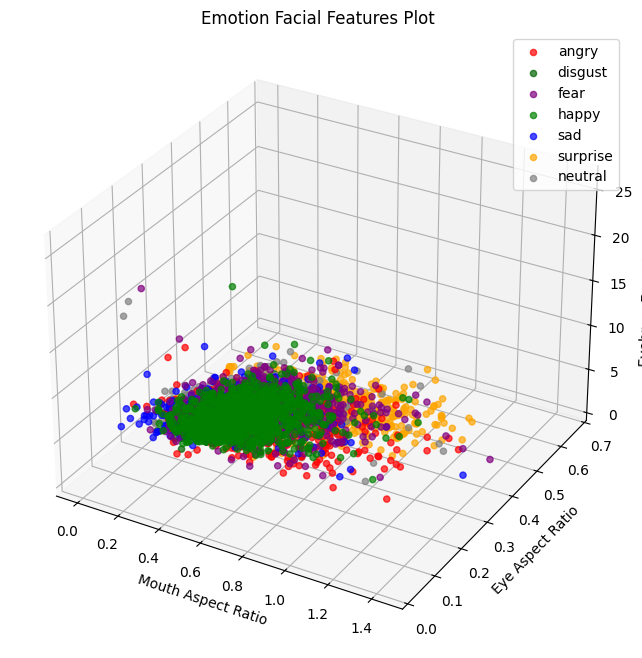

In [ ]:
# Visualize the data in 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = {
    'angry': 'red',
    'disgust': 'darkgreen',
    'fear': 'purple',
    'happy': 'green',
    'sad': 'blue',
    'surprise': 'orange',
    'neutral': 'gray'}

# Filter data for each emotion and create separate scatter plots
for emotion in emotions:
    emotion_data = df[df['emotion'] == emotion]

    ax.scatter(
        emotion_data['mouth_aspect_ratio'],
        emotion_data['average_eye_aspect_ratio'],
        emotion_data['average_eyebrow_eye_distance'],
        c=colors[emotion],
        label=emotion,
        alpha=0.7
    )

ax.set_title('Emotion Facial Features Plot')
ax.set_xlabel('Mouth Aspect Ratio')
ax.set_ylabel('Eye Aspect Ratio')
ax.set_zlabel('Eyebrow-Eye Distance')
ax.legend()
plt.show()

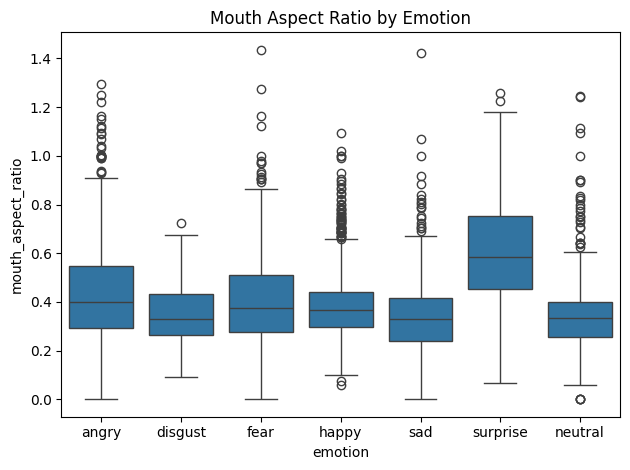

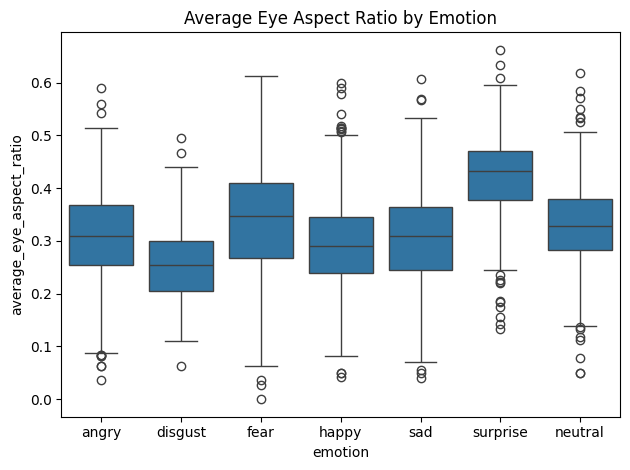

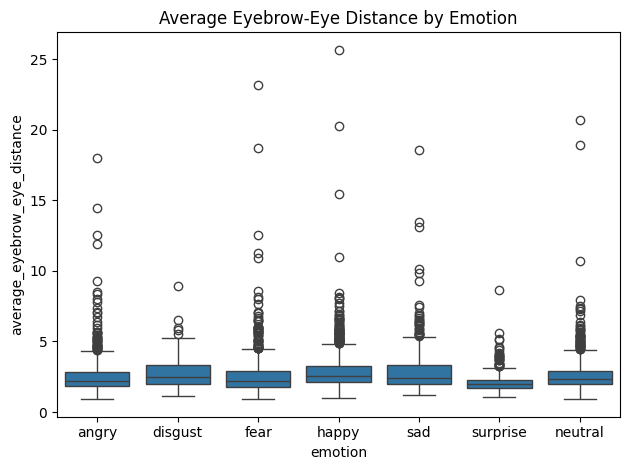

In [ ]:
sns.boxplot(x='emotion', y='mouth_aspect_ratio', data=df)
plt.title('Mouth Aspect Ratio by Emotion')
plt.tight_layout()
plt.show()

sns.boxplot(x='emotion', y='average_eye_aspect_ratio', data=df)
plt.title('Average Eye Aspect Ratio by Emotion')
plt.tight_layout()
plt.show()

sns.boxplot(x='emotion', y='average_eyebrow_eye_distance', data=df)
plt.title('Average Eyebrow-Eye Distance by Emotion')
plt.tight_layout()
plt.show()


In [ ]:
# Split the dataset into features and target
X = df.drop('emotion', axis=1)
y = df['emotion']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Process the features data only (not the target labels)
# Drop constant features
X_train = X_train.loc[:, X_train.nunique() > 1]

# Calculate correlation matrix on numeric data
corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
X_train = X_train.drop(columns=to_drop)
X_test = X_test[X_train.columns]

print(f"Columns dropped: {to_drop}")
print(f"Columns in training set: {X_train.columns}")

# Replace infinities and very large values with NaN, then fill with some reasonable value
import numpy as np
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Fill NaN values with column medians (more robust than mean for outliers)
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())  # Use train medians for test set too

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Columns dropped: ['mouth_aspect_ratio', 'right_eye_height', 'average_eye_height', 'left_eye_aspect_ratio', 'right_eye_aspect_ratio', 'average_eye_aspect_ratio', 'right_eyebrow_eye_distance', 'x_1', 'y_1', 'x_2', 'y_2', 'x_3', 'y_3', 'x_4', 'y_4', 'x_5', 'y_5', 'x_6', 'y_6', 'x_7', 'y_7', 'x_8', 'y_8', 'x_9', 'y_9', 'x_10', 'y_10', 'x_11', 'y_11', 'x_12', 'y_12', 'x_13', 'y_13', 'x_14', 'y_14', 'x_15', 'y_15', 'x_16', 'y_16', 'y_17', 'x_18', 'y_18', 'x_19', 'y_19', 'x_20', 'y_20', 'x_21', 'y_21', 'x_22', 'y_22', 'x_23', 'y_23', 'x_24', 'y_24', 'x_25', 'y_25', 'x_26', 'y_26', 'x_27', 'y_27', 'x_28', 'y_28', 'x_29', 'y_29', 'x_30', 'y_30', 'x_31', 'y_31', 'x_32', 'y_32', 'x_33', 'y_33', 'x_34', 'y_34', 'x_35', 'y_35', 'x_36', 'y_36', 'x_37', 'y_37', 'x_38', 'y_38', 'x_39', 'y_39', 'x_40', 'y_40', 'x_41', 'y_41', 'x_42', 'y_42', 'x_43', 'y_43', 'x_44', 'y_44', 'x_45', 'y_45', 'x_46', 'y_46', 'x_47', 'y_47', 'x_48', 'x_49', 'y_49', 'x_50', 'y_50', 'x_51', 'y_51', 'x_52', 'y_52', 'x_53', 'y_

In [ ]:
print(f"Training set: {X_train_scaled.shape}")
print(f"Testing set: {X_test_scaled.shape}")

Training set: (3966, 11)
Testing set: (992, 11)


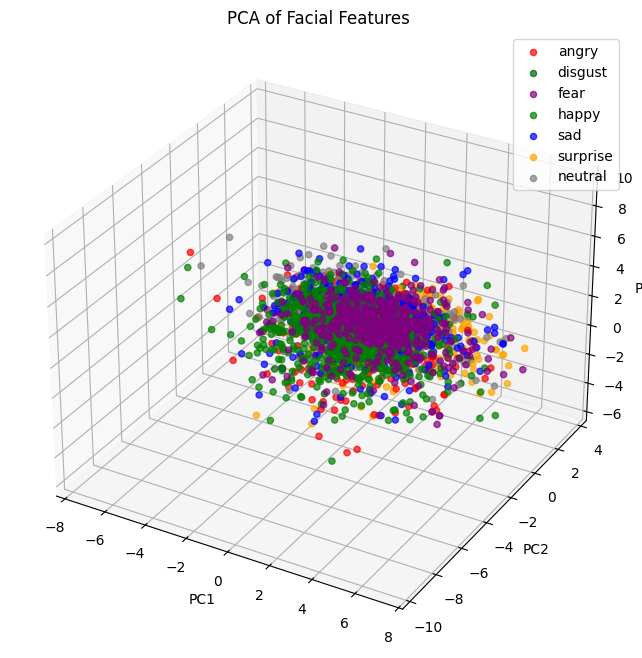

In [ ]:
# Apply PCA for visualization
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_train_scaled)

# Visualize the data in 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for emotion in emotions:
    indices = y_train == emotion
    ax.scatter(X_pca[indices, 0], X_pca[indices, 1], X_pca[indices, 2],
              c=colors[emotion], label=emotion, alpha=0.7)

ax.set_title('PCA of Facial Features')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.legend()
plt.show()


Running baseline KNN with all features...
k=1, Accuracy=0.3921
k=2, Accuracy=0.3800
k=3, Accuracy=0.3952
k=4, Accuracy=0.4345
k=5, Accuracy=0.4415
k=6, Accuracy=0.4506
k=7, Accuracy=0.4597
k=8, Accuracy=0.4728
k=9, Accuracy=0.4798
k=10, Accuracy=0.4849
k=11, Accuracy=0.4778
k=12, Accuracy=0.4728
k=13, Accuracy=0.4728
k=14, Accuracy=0.4748
k=15, Accuracy=0.4768
k=16, Accuracy=0.4778
k=17, Accuracy=0.4808
k=18, Accuracy=0.4698
k=19, Accuracy=0.4688
k=20, Accuracy=0.4708
Best k value: 10


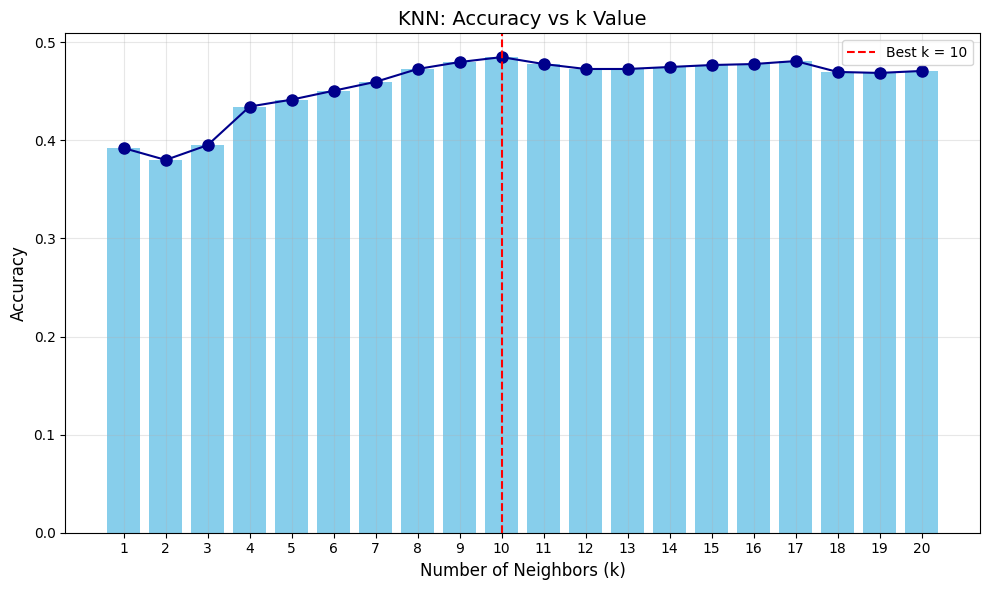

In [ ]:
# Optimized KNN with minimal feature sets
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. First, run baseline KNN with all features to get benchmark performance
print("Running baseline KNN with all features...")
k_values = range(1, 21)
k_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    score = knn.score(X_test_scaled, y_test)
    k_scores.append(score)
    print(f"k={k}, Accuracy={score:.4f}")

# Choose best k for baseline
best_k = k_values[np.argmax(k_scores)]
print(f"Best k value: {best_k}")

# Plot the k values vs accuracy
plt.figure(figsize=(10, 6))
plt.bar(k_values, k_scores, color='skyblue')
plt.plot(k_values, k_scores, 'o-', color='darkblue', markersize=8)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
plt.xlabel('Number of Neighbors (k)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('KNN: Accuracy vs k Value', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.legend()
plt.tight_layout()
plt.show()

knn_baseline = KNeighborsClassifier(n_neighbors=best_k)
knn_baseline.fit(X_train_scaled, y_train)
y_pred_baseline = knn_baseline.predict(X_test_scaled)
baseline_report = classification_report(y_test, y_pred_baseline, output_dict=True)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Identifying top features for each emotion...
emotion_models = {}
emotion_features = {}
emotion_k_scores = {}

for emotion in emotions:
    # Create binary classification problem: this emotion vs. rest
    y_train_binary = (y_train == emotion).astype(int)
    y_test_binary = (y_test == emotion).astype(int)

    # Select best 3 features for this specific emotion
    selector = SelectKBest(f_classif, k=3)
    selector.fit(X_train_scaled, y_train_binary)

    # Get feature indices that were selected
    selected_indices = selector.get_support(indices=True)
    # Get feature names from indices
    selected_features = X_train.columns[selected_indices].tolist()
    emotion_features[emotion] = selected_features

    print(f"\nTop 3 features for '{emotion}':")
    for feature in selected_features:
        print(f"- {feature}")

    # Find optimal k for these 3 features
    emotion_k_scores[emotion] = []

    # Make sure we extract the selected features properly
    X_train_emotion = X_train_scaled.iloc[:, selected_indices] if hasattr(X_train_scaled, 'iloc') else X_train_scaled[:, selected_indices]
    X_test_emotion = X_test_scaled.iloc[:, selected_indices] if hasattr(X_test_scaled, 'iloc') else X_test_scaled[:, selected_indices]

    best_accuracy = 0
    best_f1 = 0
    best_emotion_k = 1

    for k in range(1, 11):  # Try k values from 1 to 10
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_emotion, y_train_binary)
        y_pred = knn.predict(X_test_emotion)
        accuracy = accuracy_score(y_test_binary, y_pred)
        f1 = f1_score(y_test_binary, y_pred)

        emotion_k_scores[emotion].append(accuracy)

        # Track the best k
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_f1 = f1
            best_emotion_k = k

    print(f"Best k for '{emotion}': {best_emotion_k}. Accuracy: {best_accuracy:.4f}. F1: {best_f1:.4f}")

    # Create specialized model for this emotion using the best k
    emotion_knn = KNeighborsClassifier(n_neighbors=best_emotion_k)
    emotion_knn.fit(X_train_emotion, y_train_binary)
    emotion_models[emotion] = (emotion_knn, selected_indices)


Top 3 features for 'angry':
- mouth_width
- left_eyebrow_eye_distance
- y_0
Best k for 'angry': 8. Accuracy: 0.8518. F1: 0.0134

Top 3 features for 'disgust':
- right_eye_width
- left_eye_height
- y_48
Best k for 'disgust': 2. Accuracy: 0.9819. F1: 0.0000

Top 3 features for 'fear':
- left_eye_width
- left_eye_height
- y_48
Best k for 'fear': 8. Accuracy: 0.8690. F1: 0.0000

Top 3 features for 'happy':
- mouth_width
- left_eye_height
- y_48
Best k for 'happy': 10. Accuracy: 0.8125. F1: 0.6141

Top 3 features for 'sad':
- mouth_width
- mouth_height
- left_eye_height
Best k for 'sad': 8. Accuracy: 0.8750. F1: 0.0159

Top 3 features for 'surprise':
- mouth_height
- left_eye_height
- left_eyebrow_eye_distance
Best k for 'surprise': 9. Accuracy: 0.8871. F1: 0.4167

Top 3 features for 'neutral':
- mouth_width
- mouth_height
- y_48
Best k for 'neutral': 2. Accuracy: 0.8054. F1: 0.1422


In [ ]:
# 3. Create a multi-model ensemble approach with minimal features
print("\nRunning ensemble prediction with specialized models...")
# For each test sample, get predictions from each emotion-specific model
y_emotion_scores = np.zeros((len(X_test_scaled), len(emotions)))

for i, emotion in enumerate(emotions):
    model, feature_indices = emotion_models[emotion]

    # Extract the correct features using the indices
    if hasattr(X_test_scaled, 'iloc'):
        # If X_test_scaled is a DataFrame
        X_test_emotion = X_test_scaled.iloc[:, feature_indices]
    else:
        # If X_test_scaled is a numpy array
        X_test_emotion = X_test_scaled[:, feature_indices]

    # Get probability scores for the positive class (the specific emotion)
    probabilities = model.predict_proba(X_test_emotion)[:, 1]
    y_emotion_scores[:, i] = probabilities

# For each sample, predict the emotion with highest probability
y_pred_ensemble = np.array(emotions)[np.argmax(y_emotion_scores, axis=1)]


Running ensemble prediction with specialized models...


In [ ]:
# 4. Alternative: Create one model with combined top features (6-9 features total)
print("\nRunning combined top features model...")
# Collect unique features from top indices of each emotion
all_top_indices = []
for _, feature_indices in emotion_models.values():
    all_top_indices.extend(feature_indices)
unique_top_indices = list(set(all_top_indices))

# Get the feature names for display
if hasattr(X_train, 'columns'):
    unique_top_features = X_train.columns[unique_top_indices].tolist()
else:
    unique_top_features = [f"Feature {i}" for i in unique_top_indices]

print(f"Combined unique features: {len(unique_top_features)}")
print(unique_top_features)

# Extract the combined features
if hasattr(X_train_scaled, 'iloc'):
    X_train_combined = X_train_scaled.iloc[:, unique_top_indices]
    X_test_combined = X_test_scaled.iloc[:, unique_top_indices]
else:
    X_train_combined = X_train_scaled[:, unique_top_indices]
    X_test_combined = X_test_scaled[:, unique_top_indices]

# Find optimal k for the combined feature set
combined_k_scores = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_combined, y_train)
    score = knn.score(X_test_combined, y_test)
    combined_k_scores.append(score)

best_combined_k = range(1, 21)[np.argmax(combined_k_scores)]
print(f"Best k for combined features: {best_combined_k}")

# Train on combined features
combined_knn = KNeighborsClassifier(n_neighbors=best_combined_k)
combined_knn.fit(X_train_combined, y_train)
y_pred_combined = combined_knn.predict(X_test_combined)
combined_report = classification_report(y_test, y_pred_combined, output_dict=True)


Running combined top features model...
Combined unique features: 8
['mouth_width', 'mouth_height', 'left_eye_width', 'right_eye_width', 'left_eye_height', 'left_eyebrow_eye_distance', 'y_0', 'y_48']
Best k for combined features: 14


In [ ]:
# After generating y_pred_ensemble, calculate performance metrics
ensemble_accuracy = accuracy_score(y_test, y_pred_ensemble)
ensemble_report = classification_report(y_test, y_pred_ensemble, output_dict=True)

# 5. Compare the approaches
print("\n===== PERFORMANCE COMPARISON =====")

print("\nBaseline (All Features):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
for emotion in emotions:
    print(f"{emotion}: F1={baseline_report[emotion]['f1-score']:.4f}")

print("\nEnsemble of Emotion-Specific Models (3 features each):")
print(f"Accuracy: {ensemble_accuracy:.4f}")
for emotion in emotions:
    print(f"{emotion}: F1={ensemble_report[emotion]['f1-score']:.4f}")

print("\nCombined Top Features Model ({} features):".format(len(unique_top_features)))
print(f"Accuracy: {accuracy_score(y_test, y_pred_combined):.4f}")
for emotion in emotions:
    print(f"{emotion}: F1={combined_report[emotion]['f1-score']:.4f}")


===== PERFORMANCE COMPARISON =====

Baseline (All Features):
Accuracy: 0.4849
angry: F1=0.2845
disgust: F1=0.0909
fear: F1=0.2735
happy: F1=0.7131
sad: F1=0.1828
surprise: F1=0.6325
neutral: F1=0.4635

Ensemble of Emotion-Specific Models (3 features each):
Accuracy: 0.3962
angry: F1=0.2338
disgust: F1=0.0455
fear: F1=0.1872
happy: F1=0.6471
sad: F1=0.0722
surprise: F1=0.5242
neutral: F1=0.3476

Combined Top Features Model (8 features):
Accuracy: 0.4657
angry: F1=0.3077
disgust: F1=0.0000
fear: F1=0.0905
happy: F1=0.6968
sad: F1=0.2128
surprise: F1=0.5796
neutral: F1=0.4593



===== SELECTING BEST MODEL =====
Best approach based on minimum F1 score: Baseline


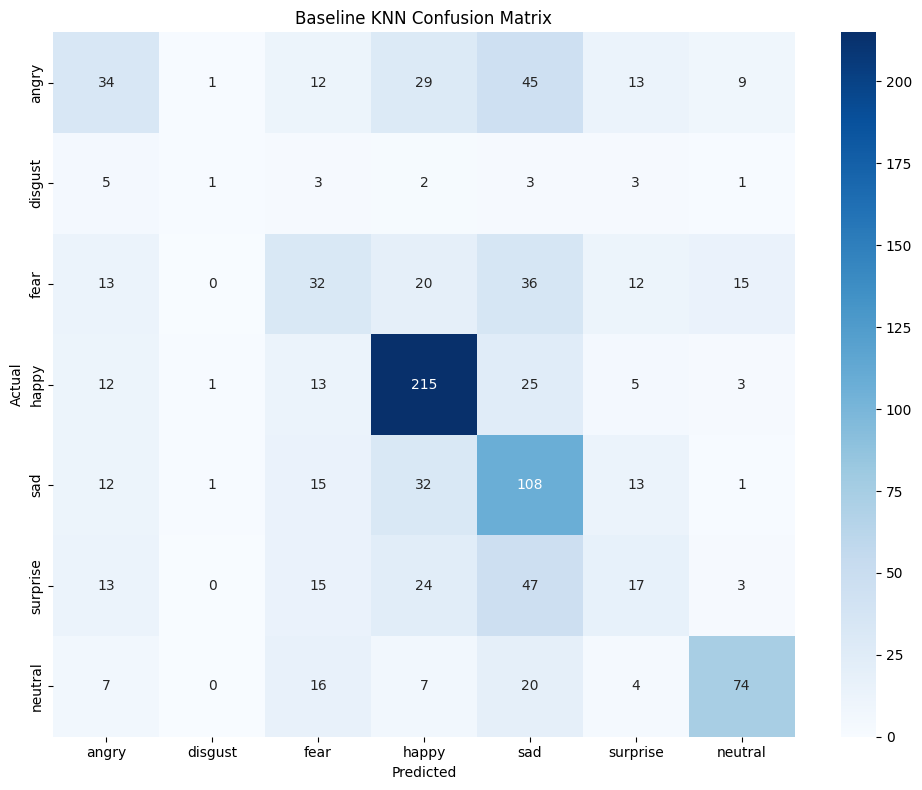


Best model: Baseline
Feature count: 11
k value: 10

Selected features:
- mouth_width
- mouth_height
- left_eye_width
- right_eye_width
- left_eye_height
- left_eyebrow_eye_distance
- average_eyebrow_eye_distance
- x_0
- y_0
- x_17
- y_48

Feature importance saved to 'emotion_feature_importance.csv'


In [ ]:
# 6. Identify the best approach
print("\n===== SELECTING BEST MODEL =====")
baseline_min_f1 = min([baseline_report[e]['f1-score'] for e in emotions])
ensemble_min_f1 = min([ensemble_report[e]['f1-score'] for e in emotions])
combined_min_f1 = min([combined_report[e]['f1-score'] for e in emotions])

min_f1_scores = {
    "Baseline": baseline_min_f1,
    "Ensemble": ensemble_min_f1,
    "Combined": combined_min_f1
}

best_approach = max(min_f1_scores.items(), key=lambda x: x[1])[0]
print(f"Best approach based on minimum F1 score: {best_approach}")

# 7. Visualize the confusion matrix for the best model
plt.figure(figsize=(10, 8))
if best_approach == "Baseline":
    cm = confusion_matrix(y_test, y_pred_baseline)
    title = "Baseline KNN Confusion Matrix"
    selected_features = X_train.columns.tolist()
    best_k_final = best_k
elif best_approach == "Ensemble":
    cm = confusion_matrix(y_test, y_pred_ensemble)
    title = "Ensemble KNN Confusion Matrix"
    selected_features = unique_top_features  # For reference only
    best_k_final = "Multiple"  # Each emotion has its own k
else:  # Combined
    cm = confusion_matrix(y_test, y_pred_combined)
    title = "Combined Top Features KNN Confusion Matrix"
    selected_features = unique_top_features
    best_k_final = best_combined_k

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotions, yticklabels=emotions)
plt.title(title)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# 8. Save the best model information
print(f"\nBest model: {best_approach}")
print(f"Feature count: {len(selected_features)}")
if best_approach != "Ensemble":
    print(f"k value: {best_k_final}")

print("\nSelected features:")
for feature in selected_features:
    print(f"- {feature}")

# Create a DataFrame with feature importance info for each emotion
feature_importance_df = pd.DataFrame(index=X_train.columns)
for emotion in emotions:
    # Create binary target
    y_train_binary = (y_train == emotion).astype(int)

    # Get feature scores
    selector = SelectKBest(f_classif)
    selector.fit(X_train_scaled, y_train_binary)

    # Store scores in dataframe
    feature_importance_df[emotion] = selector.scores_

# Save detailed feature importance information for future reference
feature_importance_df.to_csv('emotion_feature_importance.csv')
print("\nFeature importance saved to 'emotion_feature_importance.csv'")
knn_accuracy = accuracy_score(y_test, y_pred_baseline)



--- Support Vector Machine (SVM) ---
SVM Accuracy: 0.4929

SVM Classification Report:
              precision    recall  f1-score   support

       angry       0.47      0.27      0.34       143
     disgust       0.00      0.00      0.00        18
        fear       0.27      0.10      0.15       128
       happy       0.68      0.79      0.73       274
     neutral       0.38      0.65      0.48       182
         sad       0.24      0.18      0.21       119
    surprise       0.59      0.63      0.61       128

    accuracy                           0.49       992
   macro avg       0.37      0.38      0.36       992
weighted avg       0.46      0.49      0.46       992



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


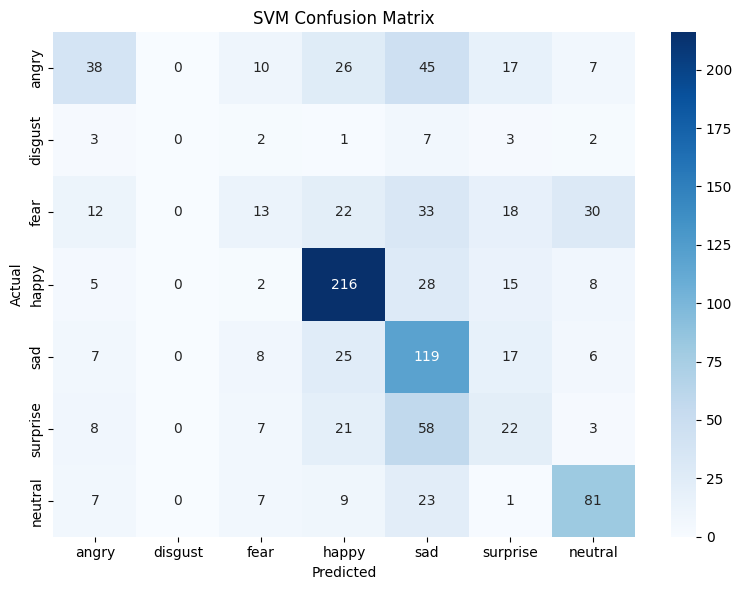

In [ ]:
# 5. Support Vector Machine (SVM)
print("\n--- Support Vector Machine (SVM) ---")

# Train SVM model
svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

# Evaluate SVM model
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {svm_accuracy:.4f}")
print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotions, yticklabels=emotions)
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()



--- Random Forest ---
Random Forest Accuracy: 0.4990

Random Forest Classification Report:
              precision    recall  f1-score   support

       angry       0.42      0.24      0.31       143
     disgust       0.50      0.06      0.10        18
        fear       0.40      0.19      0.26       128
       happy       0.64      0.81      0.71       274
     neutral       0.39      0.56      0.46       182
         sad       0.29      0.23      0.25       119
    surprise       0.59      0.66      0.62       128

    accuracy                           0.50       992
   macro avg       0.46      0.39      0.39       992
weighted avg       0.48      0.50      0.47       992



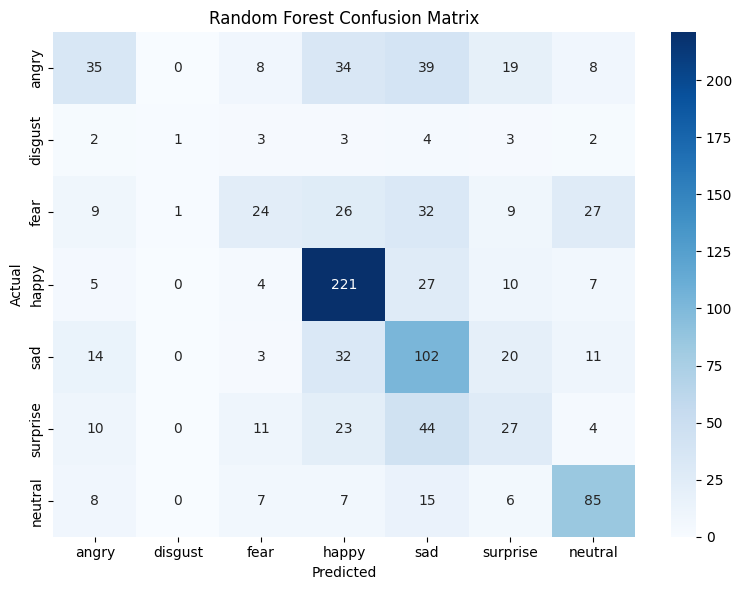

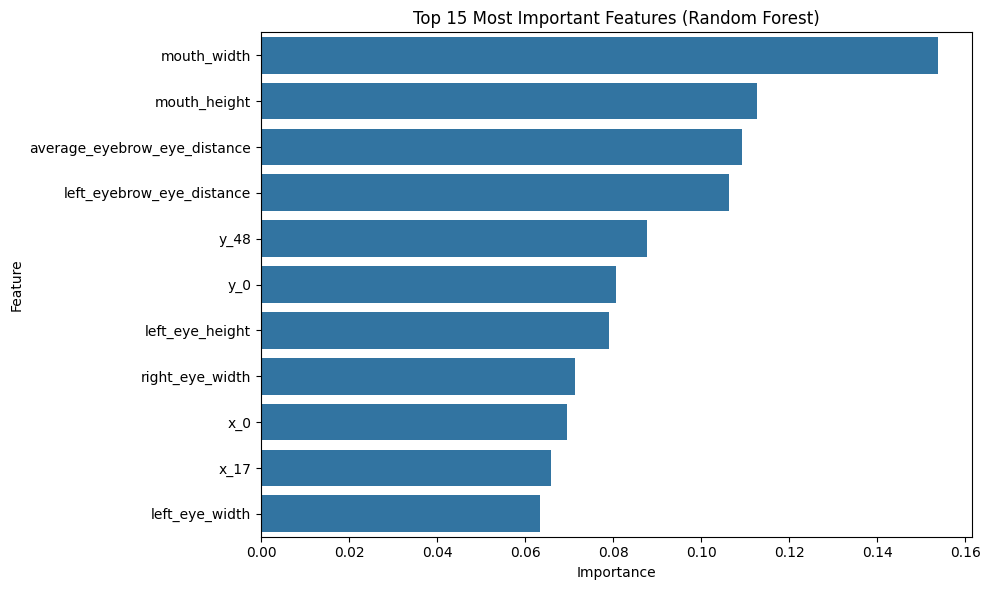

In [ ]:
# 6. Random Forest
print("\n--- Random Forest ---")

# Train Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

# Evaluate Random Forest model
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotions, yticklabels=emotions)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(15))
plt.title('Top 15 Most Important Features (Random Forest)')
plt.tight_layout()
plt.show()

In [ ]:
# 7. Other mentioned algorithms - Decision Tree
from sklearn.tree import DecisionTreeClassifier

print("\n--- Decision Tree ---")

# Train Decision Tree model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

# Evaluate Decision Tree model
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))



--- Decision Tree ---
Decision Tree Accuracy: 0.3700

Decision Tree Classification Report:
              precision    recall  f1-score   support

       angry       0.27      0.22      0.24       143
     disgust       0.09      0.11      0.10        18
        fear       0.21      0.21      0.21       128
       happy       0.58      0.58      0.58       274
     neutral       0.31      0.32      0.31       182
         sad       0.19      0.21      0.20       119
    surprise       0.51      0.50      0.51       128

    accuracy                           0.37       992
   macro avg       0.31      0.31      0.31       992
weighted avg       0.37      0.37      0.37       992



In [ ]:
# Polynomial Regression (for visualization purposes)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression

print("\n--- Logistic Regression with Polynomial Features ---")

# Create polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled[:, :2])  # Using first 2 features for simplicity
X_test_poly = poly.transform(X_test_scaled[:, :2])

# Train Logistic Regression model with polynomial features
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_poly, y_train)
y_pred_lr = lr.predict(X_test_poly)

# Evaluate model
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression with Polynomial Features Accuracy: {lr_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))



--- Logistic Regression with Polynomial Features ---
Logistic Regression with Polynomial Features Accuracy: 0.3942

Classification Report:
              precision    recall  f1-score   support

       angry       0.50      0.01      0.01       143
     disgust       0.00      0.00      0.00        18
        fear       0.00      0.00      0.00       128
       happy       0.48      0.76      0.59       274
     neutral       0.28      0.61      0.38       182
         sad       0.32      0.06      0.10       119
    surprise       0.47      0.51      0.49       128

    accuracy                           0.39       992
   macro avg       0.29      0.28      0.22       992
weighted avg       0.35      0.39      0.31       992



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



--- Model Comparison ---


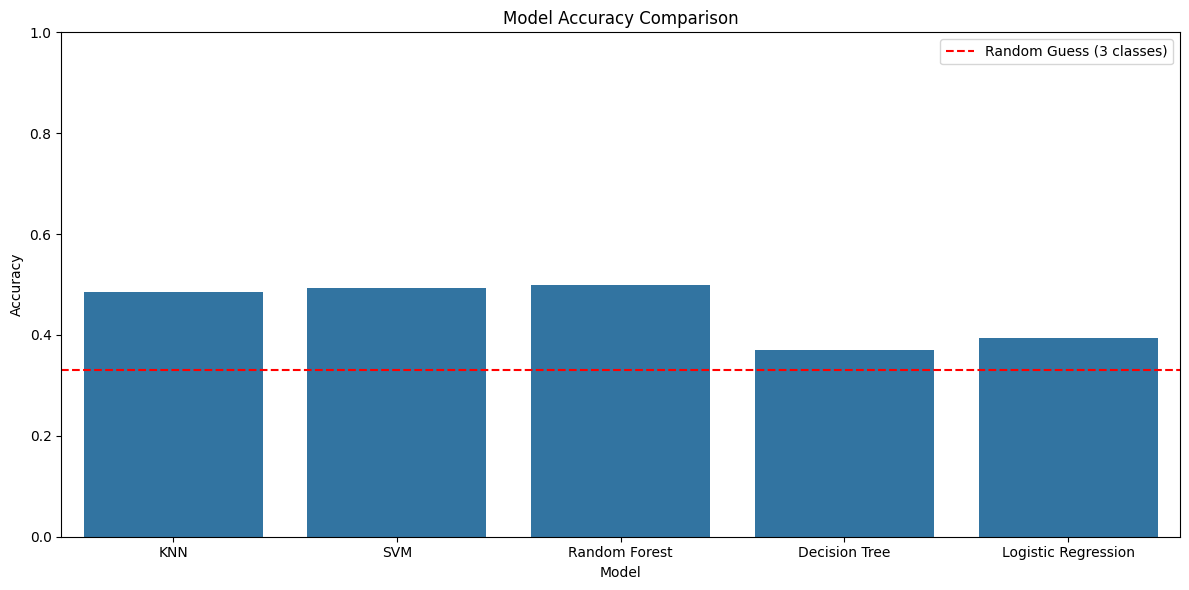


Model Accuracy Comparison:
                 Model  Accuracy
2        Random Forest  0.498992
1                  SVM  0.492944
0                  KNN  0.484879
4  Logistic Regression  0.394153
3        Decision Tree  0.369960

Visualizing predictions on sample images:


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- average_eye_aspect_ratio
- average_eye_height
- left_eye_aspect_ratio
- mouth_aspect_ratio
- right_eye_aspect_ratio
- ...
Feature names seen at fit time, yet now missing:
- x_0
- x_17
- y_0
- y_48


<Figure size 1500x500 with 0 Axes>

In [ ]:
# 8. Model Comparison
print("\n--- Model Comparison ---")

models = ["KNN", "SVM", "Random Forest", "Decision Tree", "Logistic Regression"]
accuracies = [knn_accuracy, svm_accuracy, rf_accuracy, dt_accuracy, lr_accuracy]

plt.figure(figsize=(12, 6))
sns.barplot(x=models, y=accuracies)
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.axhline(y=0.33, color='r', linestyle='--', label='Random Guess (3 classes)')
plt.legend()
plt.tight_layout()
plt.show()

# More detailed comparison
comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})
print("\nModel Accuracy Comparison:")
print(comparison_df.sort_values('Accuracy', ascending=False))

# Create a function to visualize predictions on sample images
def visualize_predictions(model, emotion_paths, emotions, n_samples=1):
    plt.figure(figsize=(15, 5*n_samples))

    for i, emotion in enumerate(emotions):
        image_files = glob(os.path.join(emotion_paths[emotion], "*.jpg"))

        for j in range(n_samples):
            if j < len(image_files):
                img_path = image_files[j]
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                # Detect landmarks
                landmarks = detect_landmarks(img_path)
                if landmarks is not None:
                    features = extract_features(landmarks)
                    if features:
                        # Remove 'emotion' if it exists
                        if 'emotion' in features:
                            del features[:]

                        # Convert to DataFrame
                        features_df = pd.DataFrame([features])

                        # Scale features
                        features_scaled = scaler.transform(features_df)

                        # Make prediction
                        prediction = model.predict(features_scaled)[0]

                        # Draw landmarks on image
                        for (x, y) in landmarks:
                            cv2.circle(img, (x, y), 2, (0, 255, 0), -1)

                        # Plot image with landmarks
                        plt.subplot(n_samples*len(emotions), 1, i*n_samples+j+1)
                        plt.imshow(img)
                        plt.title(f"Actual: {emotion}, Predicted: {prediction}")
                        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Visualize predictions using the best model (assuming it's Random Forest here)
best_model = rf  # Replace with the actual best model
print("\nVisualizing predictions on sample images:")
visualize_predictions(best_model, emotion_paths, emotions, n_samples=1)

# Generating the final conclusion
print("\n--- Final Conclusion ---")

# Get the best model
best_model_name = models[np.argmax(accuracies)]
best_acc = max(accuracies)

print(f"Best performing model: {best_model_name} with accuracy {best_acc:.4f}")
print("\nKey findings:")

if best_model_name == "Random Forest":
    print("1. The most important features for emotion classification are:")
    for i, (feature, importance) in enumerate(zip(feature_importances['Feature'].head(5),
                                               feature_importances['Importance'].head(5))):
        print(f"   {i+1}. {feature}: {importance:.4f}")

print(f"2. Hierarchical clustering identified {len(np.unique(clusters))} natural clusters in the facial feature data.")
print("3. The machine learning models were able to distinguish between the emotions with varying success:")
for model, acc in zip(models, accuracies):
    print(f"   - {model}: {acc:.4f}")

print("\nRecommendations:")
print("1. Consider using more advanced feature extraction techniques to improve classification accuracy.")
print("2. Explore ensemble methods combining the strengths of different classifiers.")
print("3. Collect more diverse training data to improve the model's generalization ability.")